# Обучение и механизм рассуждений в LLM

## Введение

Если ранее усилия исследователей были направлены на статистическое моделирование вероятности появления n-грамм и создание статических векторных представлений, то сегодня фокус сместился в сторону создания систем, способных к многоэтапным рассуждениям, планированию и самокоррекции. Большие языковые модели (LLM) больше не рассматриваются просто как хранилища сжатых знаний интернета; они интерпретируются как агенты, действующие в текстовом окружении.

Путь от модели, которая способна завершить предложение, к модели, способной решить сложную математическую задачу или написать (работающий) код, требует преодоления ряда **фундаментальных ограничений**, заложенных в базовой архитектуре трансформеров. Обученная на больших корпусах данных методом Self-Supervised Learning (или Semi-Supervised Learning) модель является мощным, но хаотичным инструментом. Она склонна к галлюцинациям, воспроизведению предвзятости, неспособна различать истину и правдоподобный вымысел. 

> Процесс превращения такой модели в полезного и безопасного ассистента называется **выравниванием** (alignment)


## Ограничения обучения с учителем

### Смещение экспозиции

Обучение с учителем (Supervised Fine-Tuning, SFT) традиционно является первым этапом в тонкой настройке предварительно обученной модели. Модель обучается на наборе данных, состоящем из пар <инструкция — эталонный ответ>. Цель: минимизации перекрестной энтропии между предсказанным распределением токенов и истинным распределением в обучающей выборке.

> SFT обладает **системными недостатками**, которые становятся критическими при решении задач, требующих точных рассуждений

Фундаментальная проблема SFT — сама методика обучения, известная как **Teacher Forcing**. В процессе обучения модель всегда получает на вход истинные токены из обучающей выборки, даже если на предыдущем шаге она сделала ошибку. Это создает искусственные условия, в которых модель никогда не сталкивается с последствиями собственных неверных решений.

Во время инференса ситуация меняется. Модель вынуждена **генерировать токены авторегрессионно:** каждый следующий токен предсказывается на основе собственных предыдущих предсказаний модели. [Это расхождение](https://arxiv.org/abs/2204.01171) между условиями обучения (контекст всегда идеален, предварительно известен) и условиями тестирования (контекст формируется самой моделью) называется **смещением экспозиции** (Exposure Bias).

Последствия этого смещения больно бьют в задачах, требующих длинных цепочек рассуждений. Если модель допускает ошибку в начале генерации (неверно интерпретирует условие задачи), то ошибка попадает в контекст и становится истиной для всех последующих шагов; [возникает каскадный эффект](https://arxiv.org/html/2510.06265v1); одна мелкая неточность влечет за собой волну последующих ошибок, приводящих к полной потере смысла или генерации ложной информации. 

> Модель, **не обученная корректировать свои ошибки**, продолжает уверенно генерировать текст, основываясь на ложных посылках

### Галлюцинации

**Галлюцинации в LLM** — не просто случайные ошибки, а системное явление, при котором модель генерирует правдоподобный, грамматически связный, но фактически ложный контент, не соответствующий реальности или входному контексту. Можно выделить несколько ключевых типов галлюцинаций. 

| Тип галлюцинации | Описание механизма | Пример из практики |
| :--- | :--- | :--- |
| **Фактическая фабрикация** (придумала то, чего нет) | Генерация несуществующих объектов, дат или законов на основе вероятностных ассоциаций слов. | Модель ссылается на Федеральный закон о персональных данных 2022 года в РФ, детально описывая его требования, хотя такого закона не существует. |
| **Смешение сущностей** (перепутала характеристики того, что есть) | Приписывание свойств одного объекта другому из-за схожести контекстов в обучающей выборке. | Утверждение, что Apple выпустила гарнитуру Vision Pro в 2022 году и захватила 34% рынка к 2023 году (реальный релиз был позже). |
| **Ложная атрибуция** (перепутала сказку с былью) | Отношение к вымышленным персонажам как к реальным историческим фигурам. | Генерация биографии Дамблдора как реального британского педагога XX века. |
| **Ошибка рассуждения** (не смогла посчитать или сделать логический вывод) | Логически неверный вывод из верных посылок из-за неспособности удержать контекст. | В задаче "У М.Ю. есть 5 синих шаров..." модель просто складывает все числа в тексте. |

Помимо внутренней проблемы SFT также страдает от качества самих данных. Модели, обученные на интернет-корпусах, наследуют предвзятости и стереотипы. Если в обучающих данных содержатся противоречивые факты, то модель будет воспроизводить эту неопределенность в виде галлюцинаций. 

Особой проблемой является **сикофантство** (sycophancy) — склонность модели соглашаться с мнением пользователя (даже если оно заведомо ложно) или подстраивать ответ под ожидаемые предпочтения пользователя в ущерб истинности. 

> Это является прямым следствием минимизации функции потерь на SFT: если в разметке эксперты ожидали вежливые и соглашающиеся ответы, то модель выучит стратегию лести как наиболее оптимальную

## Обучение с подкреплением

### Постановка задачи

Для преодоления ограничений SFT (невозможность прописать идеальный ответ для каждой ситуации) индустрия пошла за OpenAI и перешла к методологии Reinforcement Learning from Human Feedback (RLHF). Подход переопределяет задачу генерации текста как задачу **последовательного принятия решений** в условиях неопределенности.

В парадигме RLHF языковая модель рассматривается не как статический генератор, а как **обучаемый агент**. Взаимодействие агента с миром описывается через классический цикл обратной связи, адаптированный для текстовой модальности.

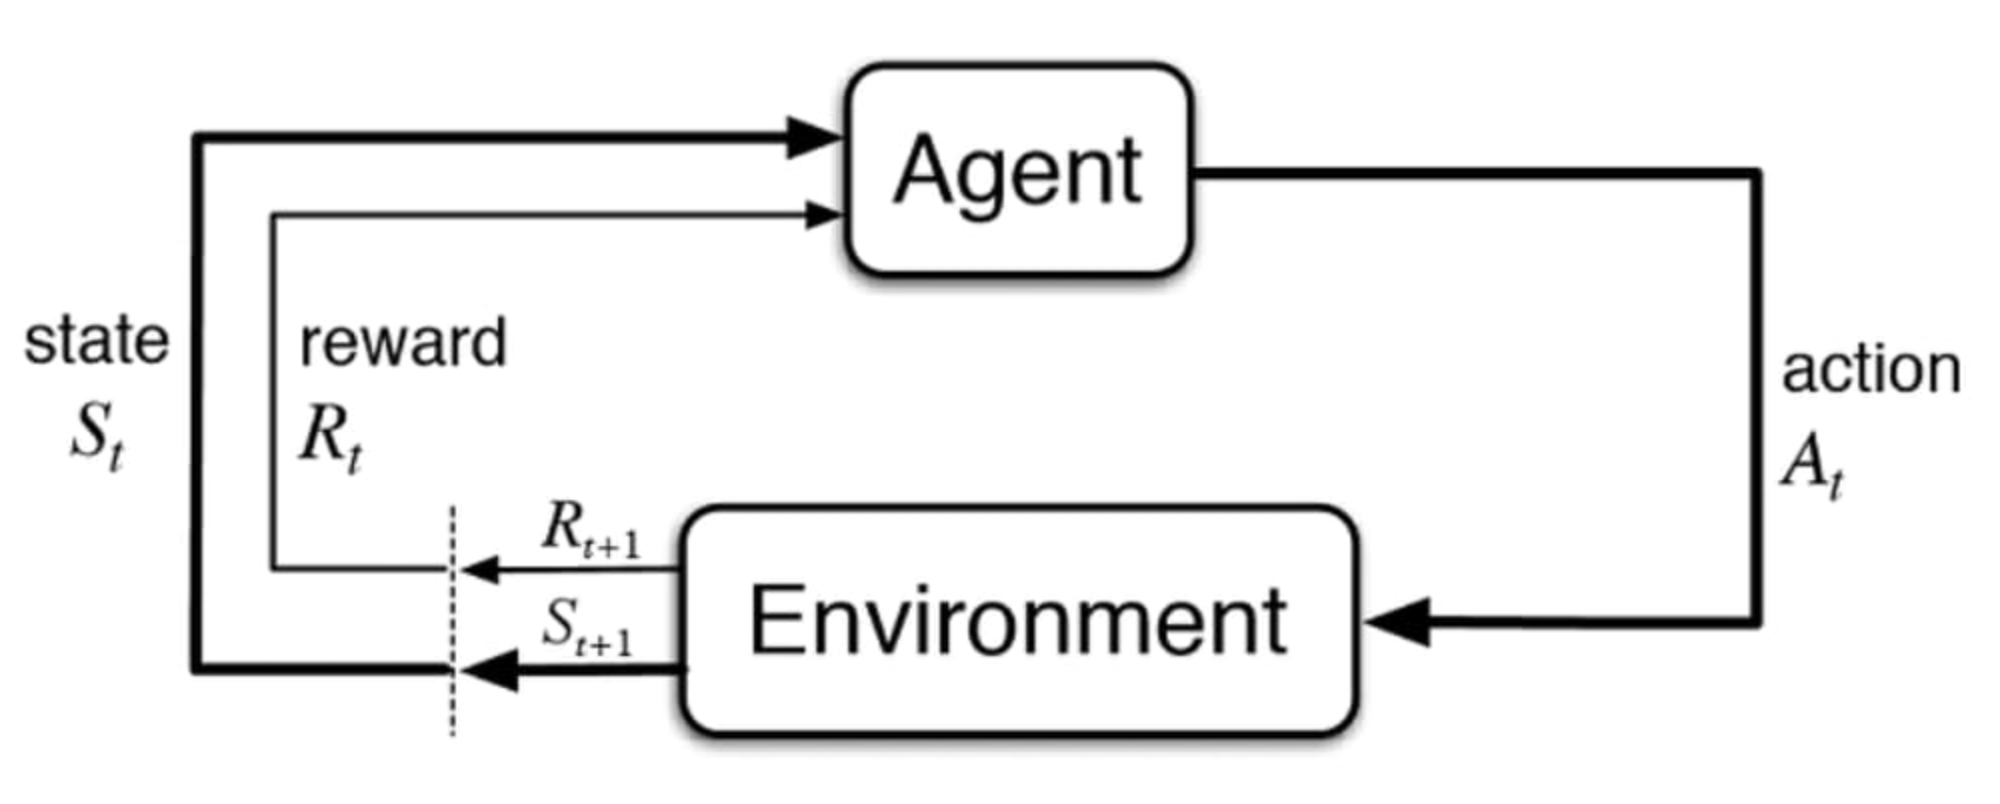

Состояние (State, $S_t$): в каждый момент времени $t$ состояние определяется как полная и доступная модели последовательность токенов. Исходный промпт пользователя ($X$) и все токены, сгенерированные агентом до текущего момента ($y_1, y_2,..., y_{t-1}$).

$$S_t = [X, y_1,..., y_{t-1}]$$

Пространство действий (Action Space, $\mathcal{A}$): множество всех возможных действий, доступных агенту. В случае LLM это полный словарь токенов.

$$A_t \in \mathcal{V}$$

Стратегия (Policy, $\pi_\theta$): условное вероятностное распределение, параметризованное весами модели $\theta$, которое определяет вероятность выбора конкретного токена $a_t$ при условии нахождения в состоянии $s_t$.

$$\pi_\theta(a_t | s_t) = P(y_t | y_{<t}, X, \theta)$$

Вознаграждение или Награда (Reward, $R_t$): скалярный сигнал, который агент получает от среды. В классическом RL вознаграждение может поступать на каждом шаге. В текстовой генерации вознаграждение является отложенным и выдается только после генерации полного ответа (терминальное состояние).

$$R = r(X, Y)$$

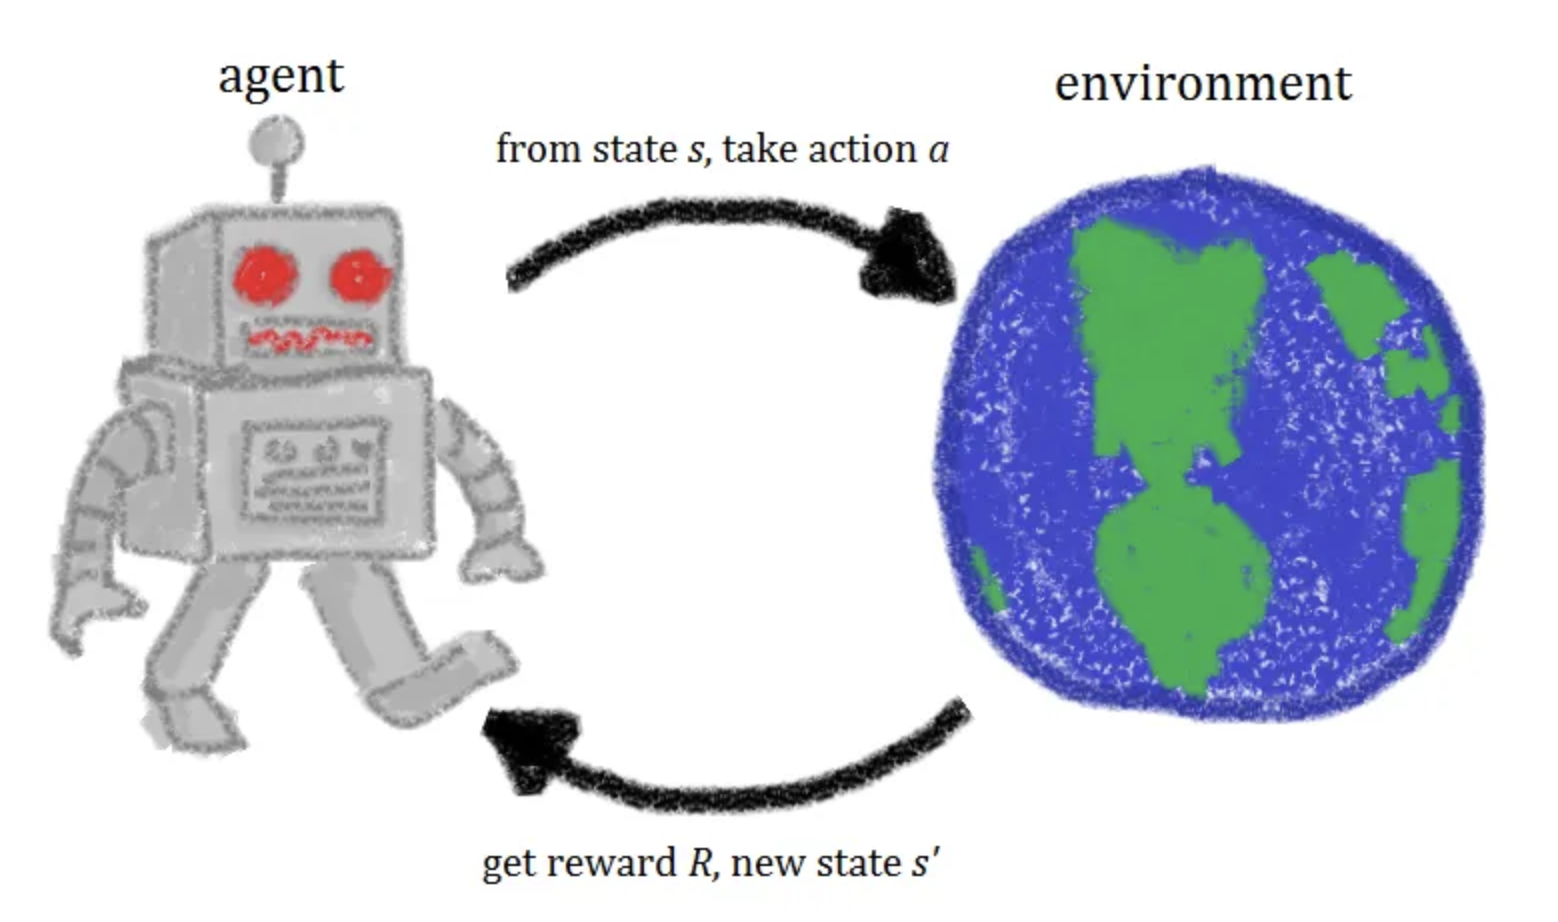

Аналогия (обучение езде на велосипеде). Агент пробует различные действия (наклоны руля), среда (физика велосипеда) реагирует изменением состояния (наклон, скорость), а вознаграждение (удержание равновесия или падение) служит сигналом для корректировки стратегии. В NLP падением является генерация токсичного или бессмысленного текста.   

> Поскольку использование людей для оценки каждого сгенерированного ответа в реальном времени невозможно, то центральным элементом RLHF становится **Модель вознаграждения** (Reward Model, RM). Это отдельная нейронная сеть, обученная имитировать человеческие предпочтения.

Процесс сбора данных и обучения RM начинается со сбора парных сравнений. Модели (после этапа SFT) подается промпт $x$, на который она генерирует два ответа-кандидата: $y_w$ (winner/chosen) и $y_l$ (loser/rejected). Человек-асессор анализирует ответы и выбирает лучший, руководствуясь (наверное, в первую очередь) критериями полезности и безвредности.

Модель вознаграждения $r_\phi(x, y)$ обучается минимизировать следующую функцию потерь (Брэдли-Терри):

$$ \mathcal{L}{RM}(\phi) = - \mathbb{E}{(x, y_w, y_l) \sim \mathcal{D}} \left[ \log \sigma (r_\phi(x, y_w) - r_\phi(x, y_l)) \right] $$

Цель функции — максимизировать разницу наград: награда победившего ответа должна быть значительно выше награды проигравшего.

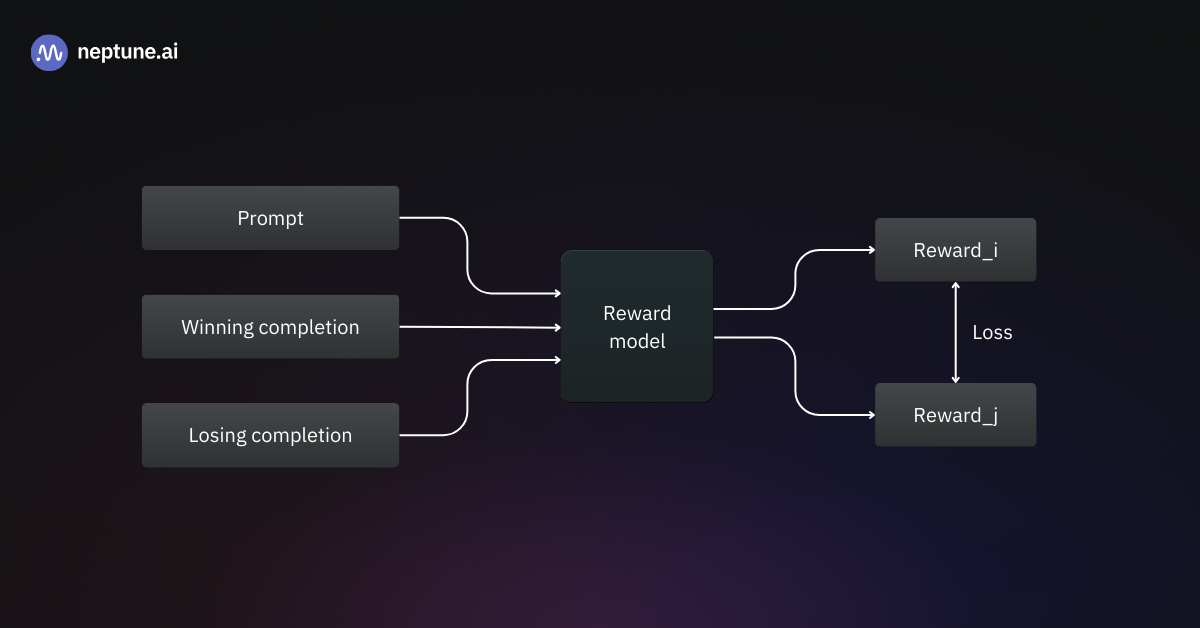

### Поиск стратегии

После обучения RM используется алгоритм **Proximal Policy Optimization** (PPO) для оптимизации стратегии основной модели. PPO решает сложную задачу: как обновить веса модели, чтобы увеличить ожидаемое вознаграждение, но не разрушить языковые способности модели.

Пусть $r_t(\theta)$ — отношение вероятности выбора действия новой стратегией к старой:

$$r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}$$

> Здесь $r_t$ — это не награда. Это коэффициент, который показывает, насколько новая стратегия вероятнее совершит это действие по сравнению со старой

Награда будет считаться следующим образом:

$$R_t(x, y) = R_{RM}(x, y) - \beta \cdot \log \left( \frac{\pi_{\theta}^{RL}(y|x)}{\pi^{ref}(y|x)} \right)$$

Где:
- $R_{RM}$ — оценка от Reward Model
- $\pi^{ref}$ — замороженная SFT-модель
- $\beta$ — коэффициент KL-штрафа


Целевая функция PPO-Clip выглядит следующим образом:

$$L^{CLIP}(\theta) = \hat{\mathbb{E}}_t \left[ \min(r_t(\theta)\hat{A}_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t) \right]$$

Где:
- $\hat{A}_t$ — оценка преимущества, показывающая, насколько действие лучше среднего действия в данном состоянии
- $\epsilon$ — гиперпараметр (обычно 0.2), задающий допустимые отклонения

Если действие было удачным ($\hat{A}_t > 0$), мы хотим увеличить вероятность этого действия (увеличить $r_t(\theta)$). Однако, если $r_t(\theta)$ становится больше $1+\epsilon$, функция clip обрезает его значение. Это означает, что PPO перестает поощрять дальнейшее изменение стратегии, как только она отклонилась от старой на величину $\epsilon$. Это предотвращает слишком жадные обновления, которые могут привести к нестабильности.

Если действие было неудачным ($\hat{A}_t < 0$), мы хотим уменьшить вероятность. Функция clip не дает отношению упасть ниже $1-\epsilon$, предотвращая обнуление вероятностей. Кроме того, к целевой функции часто добавляется бонус за энтропию $Loss = Loss^{PPO} - c \cdot H(\pi(\cdot|s_t))$, чтобы поощрять исследование (Exploration) и предотвращать преждевременную сходимость к одной определенной стратегии.

$$H(\pi(\cdot|s_t)) = - \sum_{a \in Actions} \pi(a|s_t) \ln \pi(a|s_t)$$

Чтобы посчитать $\hat{A}_t$ **нужна вторая модель** — Критик (Critic). В PPO используется архитектура Actor-Critic:
- Actor ($\pi$): выбирает действия (играет)
- Critic ($V$): предсказывает, сколько очков мы получим в будущем из этого состояния (оценивает ситуацию)

В PPO используется Generalized Advantage Estimation (GAE). Это не просто разница, а взвешенная сумма ошибок на несколько шагов вперед.

Мы смотрим, что случилось: получили награду + ценность следующего состояния $\gamma V(s_{t+1})$. Вычитаем то, что предсказывал Критик раньше: $V(s_t)$.

$$\delta_t = {R_t} + \gamma V(s_{t+1}) - V(s_t)$$

Где:
- $R_t$ — реальная награда от среды за этот шаг
- $V(s)$ — предсказание Критика (сколько очков будет в сумме)
- $\gamma$ (гамма) — коэффициент дисконтирования (насколько нам важно будущее), обычно около 0.99

$$\hat{A}_t = \sum_{k=0}^\infty (\gamma \lambda)^k \delta_{t+k}$$

Итоговая функция потерь:

$$Loss = -L^{CLIP} + L^{VF}_{MSE} - c_{ent} \cdot H(\pi)$$



## Mixture of Experts (MoE)

Параллельно с совершенствованием алгоритмов обучения развивается и архитектура моделей. Для достижения высокой производительности при сохранении вычислительной эффективности была создана архитектура Mixture of Experts (MoE) (Смесь экспертов). Этот подход позволяет значительно увеличить количество параметров модели (до триллионов), сохраняя стоимость инференса на уровне гораздо меньших моделей. [Идея появилась еще в 1991 году.](https://www.cs.toronto.edu/~hinton/absps/jjnh91.pdf)

В традиционных плотных моделях (GPT-3) каждый токен входной последовательности обрабатывается всеми слоями и всеми нейронами сети. 

> Это неэффективно: для обработки простого предлога требуется столько же вычислительных ресурсов, сколько для сложного научного термина

MoE реализует принцип разреженной активации (sparse activation). Слой Feed-Forward Network (FFN) в трансформере заменяется на набор из $N$ независимых подсетей-экспертов ($E_1,..., E_N$). Для каждого токена активируется лишь небольшое подмножество этих экспертов (обычно $k=1$ или $k=2$). Это называется условным вычислением (conditional computation).

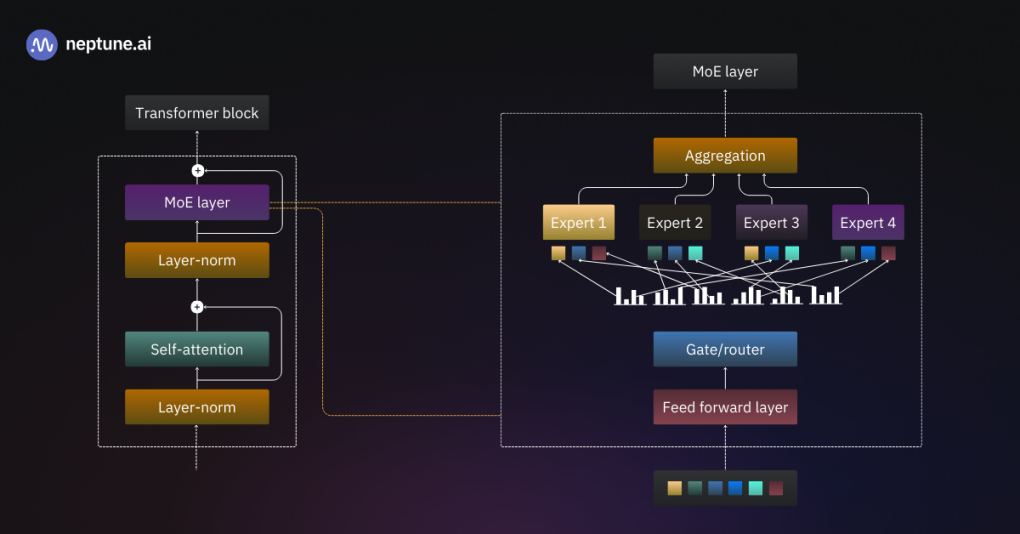

Центральным элементом MoE является Маршрутизатор (Router) или Гейт (Gate network) — $G(x)$. Это обучаемая линейная проекция.

Пусть $x$ — это входной вектор токена, а $W_g$ — обучаемая матрица весов роутера.

Сначала роутер вычисляет, насколько каждый эксперт подходит данному токену.

$$H(x) = x \cdot W_g$$

Где $H(x)$ — это вектор длиной $N$ (количество экспертов), содержащий сырые оценки совместимости. Далее выбираем индексы $k$ экспертов с самыми большими значениями в $H(x)$. Обозначим множество индексов выбранных экспертов как $\mathcal{I}$.

Функция $\text{KeepTopK}$ зануляет (или устремляет к $-\infty$) все значения, которые не попали в топ-$k$:

$$h_i'(x) =
\begin{cases}
H(x)_i, & \text{если } H(x)_i \in \text{top-}k(H(x)) \\
-\infty, & \text{иначе}
\end{cases}$$

Теперь мы применяем Softmax к отфильтрованным логитам, чтобы получить итоговые веса гейта $G(x)$. Веса выбранных экспертов будут суммироваться в единицу, а остальные будут равны нулю.

$$G(x) = \text{Softmax}(h'(x))$$

> На практике к логитам добавляют случайный шум при обучении, чтобы роутер иногда пробовал выбирать других экспертов

$$G(x) = \text{Softmax}(\text{KeepTopK}(x \cdot W_g + \epsilon, k))$$

Но даже с учетом случайного шума дисбаланс нагрузки остается проблемой. Маршрутизатор может начать отправлять большинство токенов к нескольким любимым экспертам, оставляя остальных бездействовать. Это приводит к деградации модели до уровня небольшой плотной сети.

Для решения этой проблемы вводятся два механизма:

**Auxiliary Loss (Вспомогательная функция потерь)**

К основной функции потерь добавляется штрафное слагаемое, которое растет, если распределение токенов по экспертам отклоняется от равномерного.

**Capacity Factor (Фактор емкости)**

Это гиперпараметр $C$, определяющий максимальное количество токенов, которое эксперт может обработать в одном батче. Емкость эксперта рассчитывается как:

$$\text{Capacity} = \frac{\text{Tokens in Batch}}{\text{Number of Experts}} \times C$$

Обычно $C$ выбирается в диапазоне 1.0–1.25. Если количество токенов, направленных к эксперту, превышает его емкость, то лишние токены сбрасываются. Они проходят через слой без обработки (через residual connection), что предотвращает замедление всей системы из-за одного перегруженного эксперта, но может снижать качество.

**Пример.**

Вводные данные:
- батч (Batch size): 12 токенов ($t_1, t_2, ..., t_{12}$)
- количество экспертов ($N$): 3 эксперта ($E_1, E_2, E_3$)
- Top-k: $k=1$ (каждый токен отправляется только к одному эксперту)

**Auxiliary Loss**

Общая функция потерь:

$$L_{total} = L_{task} + \alpha \cdot L_{aux}$$

Где $\alpha$ является гиперпараметром.

Добавляем к функции потерь вспомогательную оценку (Auxiliary). Чем хуже баланс, тем больше эта оценка.

$$L_{aux} = N \cdot \sum_{i=1}^N f_i \cdot P_i$$

Где:
- $f_i$ — доля токенов, реально отправленных к эксперту $i$
- $P_i$ — средняя вероятность, которую роутер предсказал для эксперта $i$

Роутер отправил по 4 токена каждому эксперту ($E_1: 4, E_2: 4, E_3: 4$). Доля $f$ для каждого: $4/12 = 1/3$. Вероятность $P$ (в среднем роутер был уверен): тоже $1/3$.

$$L_{aux} \approx 3 \cdot \left( \frac{1}{3} \cdot \frac{1}{3} + \frac{1}{3} \cdot \frac{1}{3} + \frac{1}{3} \cdot \frac{1}{3} \right) = 3 \cdot \left( \frac{1}{9} + \frac{1}{9} + \frac{1}{9} \right) = 3 \cdot \frac{3}{9} ={1}$$

Роутер отправил все 12 токенов к Эксперту 1. Эксперт 1: $f_1 = 1.0$ (100% токенов), $P_1 \approx 1.0$. Эксперты 2 и 3: $f = 0, P = 0$.

$$L_{aux} \approx 3 \cdot \left( (1 \cdot 1) + (0 \cdot 0) + (0 \cdot 0) \right) = 3 \cdot 1 = {3}$$

**Capacity Factor**

Идеальное распределение: 12 токенов / 3 эксперта = 4 токена на эксперта.

Пусть Capacity Factor ($C$) = 1.25.

$$\text{Capacity} = \frac{12}{3} \times 1.25 = 4 \times 1.25 = 5$$

Правило: каждый эксперт может принять максимум 5 токенов.

Ситуация 1. Роутер посмотрел на слова и решил распределить их так:
- к Эксперту 1: 7 токенов ($t_1$ — $t_7$)
- к Эксперту 2: 3 токена ($t_8$ — $t_{10}$)
- к Эксперту 3: 2 токена ($t_{11}, t_{12}$)

Эксперт 1: к нему пришли 7. Он берет первые 5 ($t_1...t_5$). Токены $t_6$ и $t_7$ — лишние. Они сбрасываются. Что с ними будет? Для них вектор выхода MoE слоя будет равен нулю (или равен входу, благодаря residual connection: $y = x + 0$). Это плохо для качества. 

Эксперт 2: к нему пришли 3. Он берет всех. Эксперт 3: к нему пришли 2. Он берет всех. Итог: мы потеряли качество на 2 токенах, чтобы не ждать перегруженного Эксперта 1.

> Capacity Factor работает во время обучения и инференса. **Это предохранитель.** Если Auxiliary Loss во время обучения сработал плохо и роутер все равно перегрузил кого-то из экспертов, то Capacity Factor обрежет лишнее, чтобы сервер с LLM не завис.


## Стратерии рассуждений

Даже при наличии передовой архитектуры и методов обучения базовая стратегия генерации токен за токеном (System 1) часто оказывается недостаточной для решения задач, требующих логики, планирования и арифметики. В ответ на это в последние годы возникло направление разработки когнитивных стратегий (System 2), которые эмулируют медленное, аналитическое мышление.

Согласно [теории дуального процесса мышления](https://ru.wikipedia.org/wiki/%D0%94%D1%83%D0%BC%D0%B0%D0%B9_%D0%BC%D0%B5%D0%B4%D0%BB%D0%B5%D0%BD%D0%BD%D0%BE%E2%80%A6_%D1%80%D0%B5%D1%88%D0%B0%D0%B9_%D0%B1%D1%8B%D1%81%D1%82%D1%80%D0%BE) Daniel Kahneman:
- System 1 — быстрое, интуитивное, бессознательное мышление; стандартные LLM работают так: выдают наиболее вероятное продолжение мгновенно
- System 2 — медленное, осознанное, логическое мышление, требующее усилий

Современные методы промпт-инжиниринга (Prompt Engineering) и специализированного обучения (OpenAI o1) направлены на то, чтобы переключить LLM в режим System 2. 

> Это достигается за счет принуждения модели **генерировать мысли** (reasoning traces) перед генерацией финального ответа 

### Цепочка мыслей

Chain of Thought (CoT) — стратегия, при которой модель генерирует цепочку промежуточных шагов рассуждения. Это позволяет разбить сложную задачу на последовательность простых подзадач, снижая когнитивную нагрузку на каждом шаге генерации.

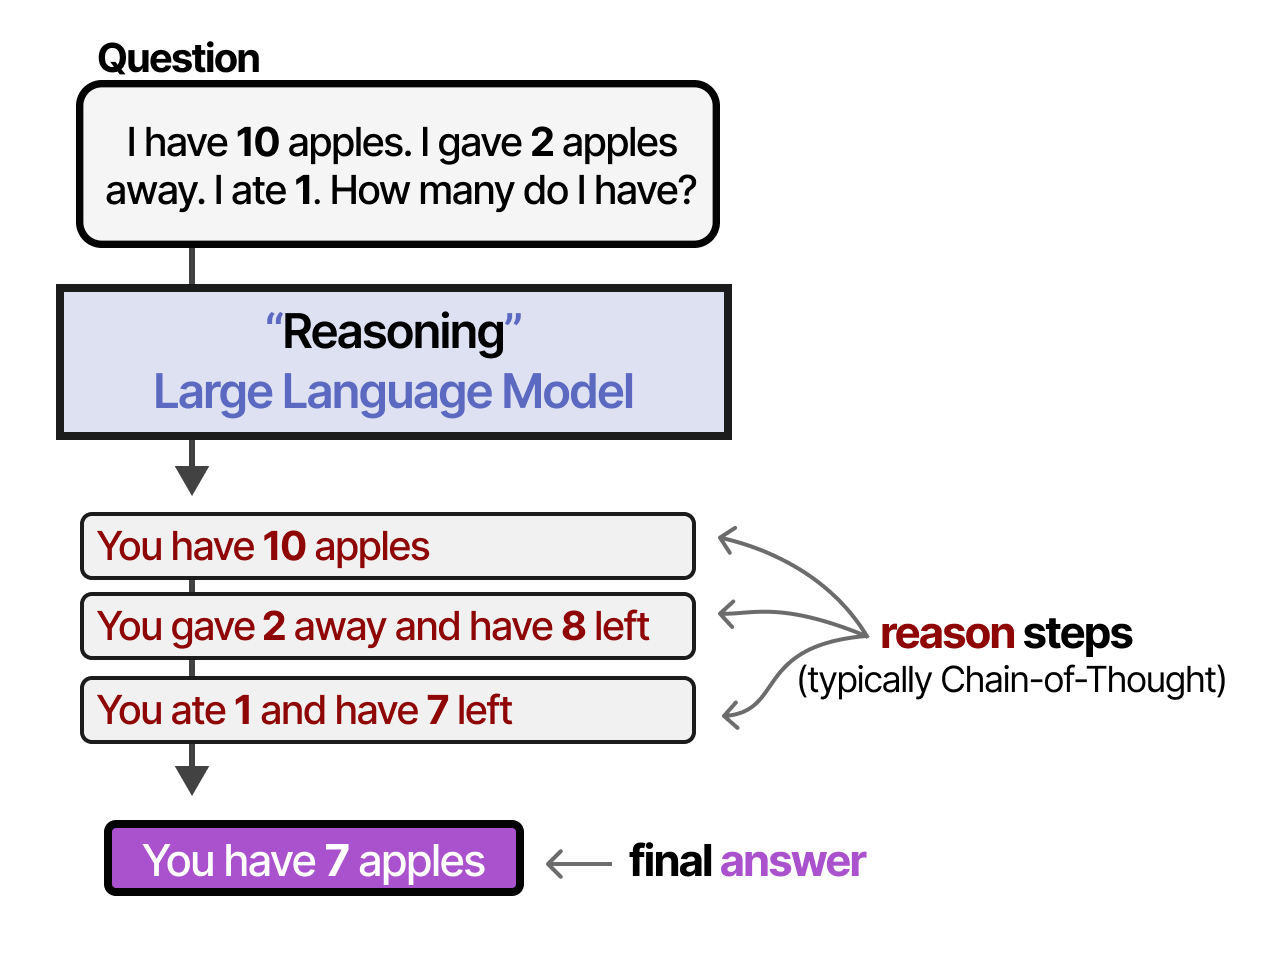

**Промтп-инжиниринг.**

Вопрос: У Роджера было 5 теннисных мячей. Он купил еще 2 банки теннисных мячей. В каждой банке по 3 мяча. Сколько мячей теперь у Роджера? Рассуждение: У Роджера изначально было 5 мячей. 2 банки по 3 мяча — это 6 мячей (2 * 3 = 6). 5 + 6 = 11. Ответ: 11.

Вопрос: В столовой было 23 яблока. На обед использовали 20. Затем купили еще 6. Сколько яблок в столовой? Рассуждение:...

> Обучение рассуждениям (Reasoning) — это важнейшее направление в развитии ИИ (именно так были созданы модели уровня OpenAI o1 или DeepSeek-R1)

#### CoT Data

Модель учится на том, что читает. Если в обучающей выборке только вопросы и короткие ответы ("Столица Франции?" — "Париж"), то модель не научится думать.

Для обучения рассуждениям наборы данных специально готовят в формате "Вопрос —> Цепочка мыслей + ответ".

Вместо пары (2x + 3 = 9, x = 3) в качестве ответа берут текст: "Чтобы найти x, сначала вычтем 3 из обеих частей уравнения: 2x = 6. Теперь разделим обе части на 2: x = 3. Ответ: 3."

> Модель начинает воспринимать размышление как неотъемлемую часть процесса генерации ответа

#### Self-Taught Reasoner

1. Модели дают сложный вопрос.
2. Она пытается сгенерировать цепочку рассуждений и ответ.
3. Если ответ неверный, попытка отбрасывается.
4. Если ответ верный, эта цепочка рассуждений (сгенерированная самой моделью) добавляется в ее же обучающий датасет.
5. Модель дообучается (fine-tune) на своих удачных решениях.

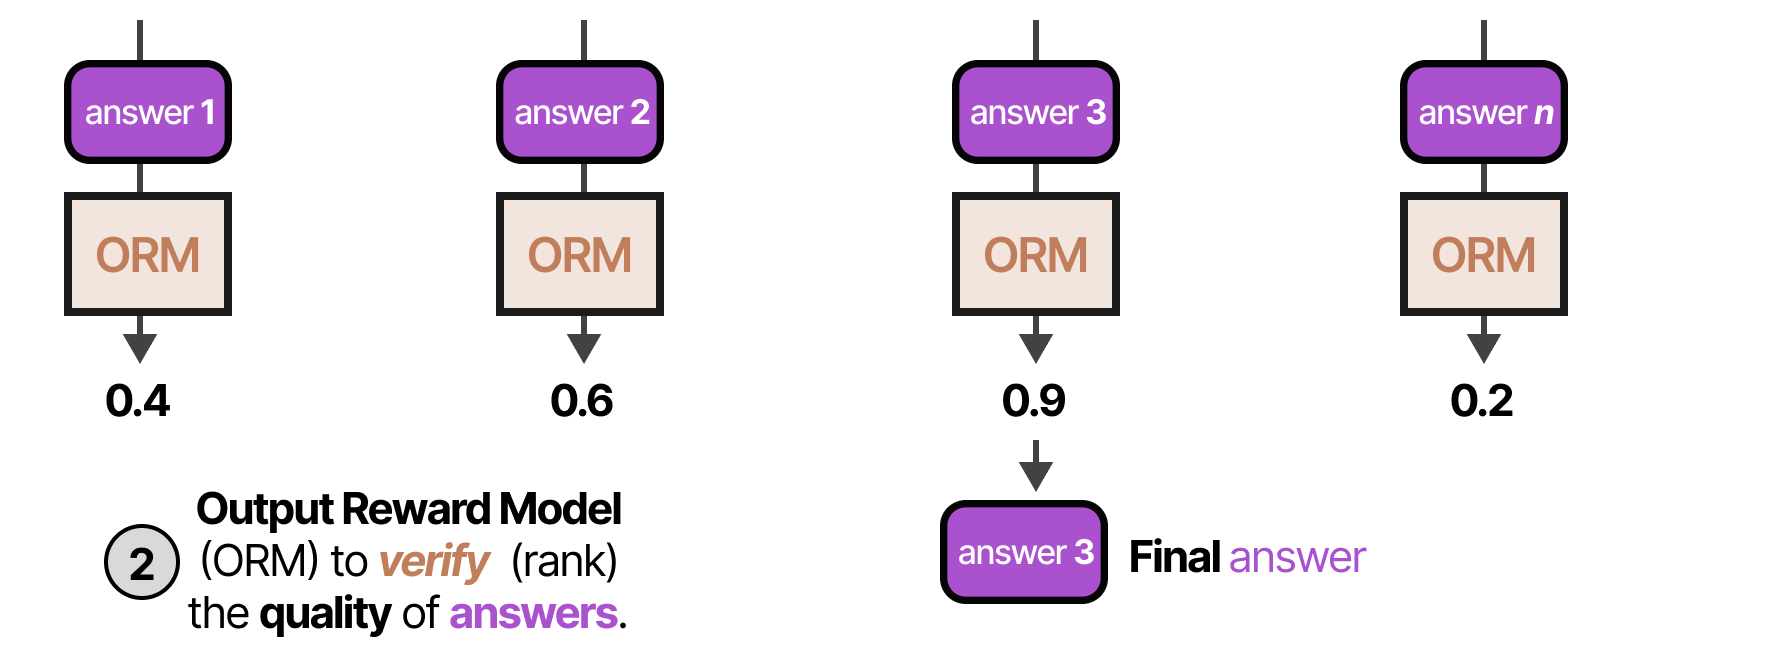

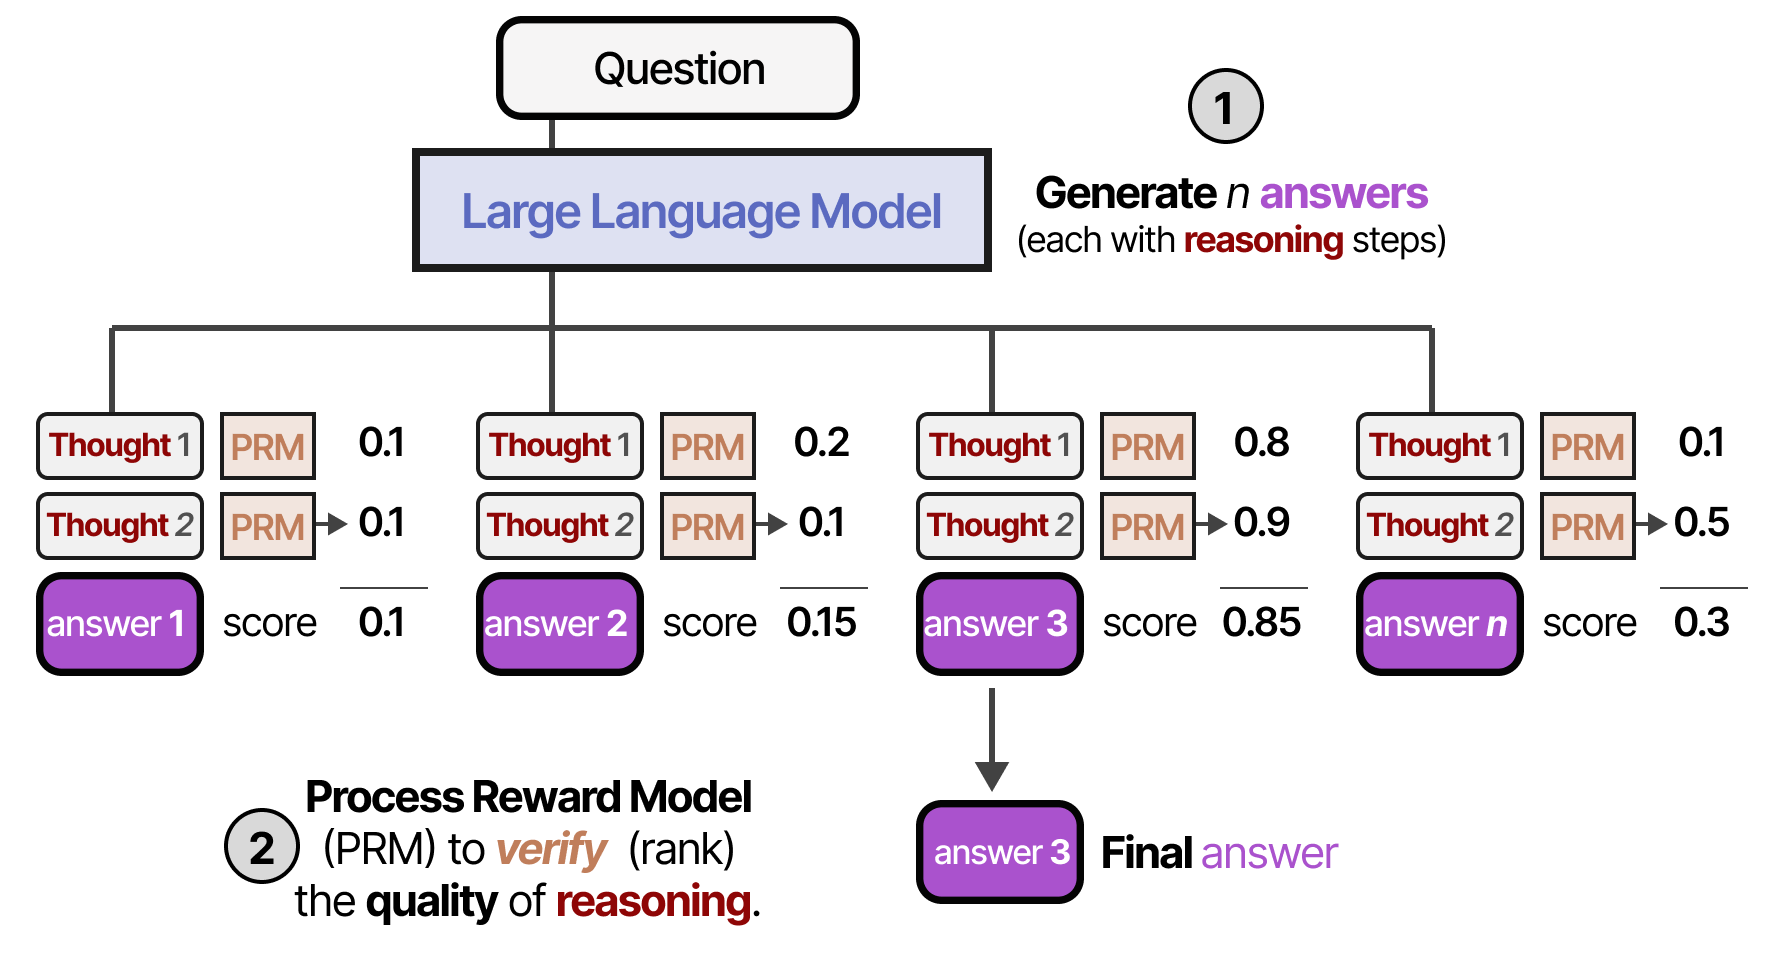

Метод **Self-Consistency** основывается на интуиции, что сложная задача часто имеет единственный верный ответ, но множество путей рассуждения, ведущих к нему. Модель запускается $N$ раз с ненулевой температурой (для разнообразия выводов). Затем применяется механизм голосования для выбора финального ответа. Это позволяет маргинализировать случайные ошибки в отдельных цепочках рассуждений.

> Вместо того чтобы считать каждый голос равным 1, можем взвешивать их на основе уверенности модели (log-probabilities) в сгенерированных токенах. Ответ, в котором модель была уверена сильнее, получает больший вес.

### Дерево мыслей

Chain of Thought имеет существенный недостаток: он линеен. Если модель ошибается на первом шаге, вся цепочка рушится, и модель не может вернуться назад. Tree of Thoughts (ToT) позволяет модели исследовать пространство решений как дерево.

**Задача:** есть 2000 рублей, на улице идет дождь, и нам нужно придумать план на вечер для двух друзей, один из которых вегетарианец.

Модель придумывает три варианта:
- Ветка А: Пойти гулять в парк
- Ветка Б: Пойти в Grisha
- Ветка В: Заказать пиццу домой и посмотреть кино

Модель анализирует каждую ветку на соответствие условиям:
Анализ Ветки А (Парк):
- Мысль: "На улице дождь. Гулять будет неприятно".
- Вердикт: тупик (модель отбрасывает этот вариант и больше о нем не думает).

Анализ Ветки Б (Grisha):
- Мысль: "Друг — вегетарианец. Ему будет нечего есть".
- Вердикт: тупик.

Анализ Ветки В (Дом + Пицца):
- Мысль: "Дома сухо (решает проблему дождя). Пиццу можно взять овощную (решает проблему вегетарианства). Это укладывается в 2000 рублей".
- Вердикт: перспективно (идем дальше по этой ветке).

Теперь модель думает только внутри варианта В:
- Под-ветка 1: Заказать пиццу с пепперони -> Нет, там мясо
- Под-ветка 2: Заказать пиццу 4 сыра -> RESPECT

**По итогу**

"Учитывая дождь и бюджет, лучший вариант — остаться дома. Давайте закажем пиццу "4 сыра" и посмотрим фильм. Это комфортно и подходит для вегетарианцев."

## Заключение

Анализ методов обучения и механизмов рассуждений в современных LLM демонстрирует переход от простой стохастической имитации текста к созданию сложных когнитивных агентов. 

Комбинация обучения с подкреплением (RLHF/DPO), эффективных разреженных архитектур (MoE) и алгоритмических стратегий рассуждения (CoT/ToT) позволяет преодолеть фундаментальные ограничения трансформеров (галлюцинации и ошибки логического вывода). Будущее развитие NLP связано с дальнейшей интеграцией процессов мышления (reasoning) непосредственно в архитектуру и функцию потерь моделей, стирая грань между обучением и инференсом.